<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
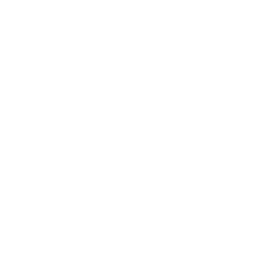
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Interpolatie van kwartaal- naar maandinstroom</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Farmaceutisch / Klinische operaties &nbsp;|&nbsp; maart 2026</p>
</div>
</div>
</div>

## Managementsamenvatting

Dit uitgewerkte voorbeeld zet **kwartaal**aantallen van klinische-trialinstroom om naar **maandelijkse** schattingen met PROC EXPAND, zodat resourceplanning op locatieniveau op een maandelijkse cadans kan draaien. De synthetische trial beslaat **vier onderzoekslocaties** in twee regio's (North America en Europe) over **acht kwartalen** (Q1 2024 tot en met Q4 2025), wat **32 kwartaalobservaties** oplevert. PROC EXPAND interpoleert de reeks van elke locatie van kwartaal- naar maandfrequentie en zet die 32 kwartaalrijen om in **96 maandrijen**. De instroomaantallen worden geïnterpoleerd met `METHOD=JOIN` (stuksgewijs lineair, waardoor elke schatting niet-negatief blijft) en de lopende cumulatieve waarde met `METHOD=SPLINE`. De geïnterpoleerde maandreeks loopt exact door de oorspronkelijke kwartaalankerpunten, dus de omzetting voegt detail binnen het kwartaal toe zonder de kwartaalcijfers te wijzigen die de studie al heeft gerapporteerd.


## Gegevensbronnen

| Bron | Beschrijving | Records |
|--------|-------------|---------|
| WORK.ENROLLMENT_QTR | Kwartaalinstroomaantallen per locatie (4 locaties x 8 kwartalen) | 32 |
| WORK.SITE_MASTER | Locatiereferentie: naam, land, regio, PI | 4 |


---

In [1]:
/* --------------------------------------------------------
   Genereer kwartaalinstroomaantallen per locatie.
   4 locaties x 8 kwartalen (Q1-2024 t/m Q4-2025) = 32 rijen.
   Een opstartcurve (langzame start, plateau) plus een lichte
   seizoensterm en kleine ruis levert een realistisch
   instroompatroon op.
   -------------------------------------------------------- */
GEGEVENS work.enrollment_qtr;
    CALL streaminit(42);
    OPMAAK quarter_date yyq7.;
    REEKS capacity[4] _temporary_ (12 9 14 8);
    DOE site_num = 1 TOT 4;
        site_id = cat('SITE-', SCHRIJVEN(site_num, z3.));
        region  = ifc(site_num <= 2, 'NOORD_AMERIKA', 'EUROPA');
        base_rate = capacity[site_num];
        DOE qtr_seq = 0 TOT 7;
            quarter_date = intnx('qtr', '01JAN2024'd, qtr_seq);
            ramp_factor  = 0.3 + 0.7 * (1 - EXP(-0.4 * qtr_seq));
            seasonal_adj = 1 + 0.15 * sin(2 * 3.14159 * qtr_seq / 4);
            noise = round(rand('normal', 0, 1.5), 1);
            enrolled_count = MAX(0,
                round(base_rate * ramp_factor * seasonal_adj + noise, 1));
            UITVOER;
        EINDE;
    EINDE;
    VERWIJDEREN site_num base_rate ramp_factor seasonal_adj noise qtr_seq;
UITVOEREN;

/* Lopende cumulatieve instroom binnen elke locatie */
PROCEDURE SORTEREN GEGEVENS=work.enrollment_qtr;
    VOLGENS site_id quarter_date;
UITVOEREN;

GEGEVENS work.enrollment_qtr;
    INSTELLEN work.enrollment_qtr;
    VOLGENS site_id;
    BEHOUDEN cum_enrolled 0;
    ALS first.site_id DAN cum_enrolled = 0;
    cum_enrolled + enrolled_count;
    cumulative_enrolled = cum_enrolled;
    VERWIJDEREN cum_enrolled;
UITVOEREN;



NOTE: DATA work.enrollment_qtr


NOTE: Wrote work.enrollment_qtr (32 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SORT data=work.enrollment_qtr

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 32 rows from work.enrollment_qtr.
NOTE: Wrote work.enrollment_qtr (32 rows, 4 columns).
NOTE: PROC SORT statement used.
NOTE: DATA work.enrollment_qtr


NOTE: Read 32 rows from work.enrollment_qtr.
NOTE: Wrote work.enrollment_qtr (32 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


In [2]:
/* --------------------------------------------------------
   Referentietabel met locatiestamgegevens (4 locaties, 2 regio's)
   -------------------------------------------------------- */
GEGEVENS work.site_master;
    LENGTE site_id $8 site_name $40 region $20 country $20 pi_name $30;
    REEKS names[4] $40 _temporary_ (
        'Metro General Hospital'   'University Medical Center'
        'London Royal Infirmary'   'Berlin Charite Campus'
    );
    REEKS countries[4] $20 _temporary_ ('USA' 'USA' 'UK' 'Germany');
    DOE i = 1 TOT 4;
        site_id   = cat('SITE-', SCHRIJVEN(i, z3.));
        site_name = names[i];
        country   = countries[i];
        region    = ifc(i <= 2, 'NOORD_AMERIKA', 'EUROPA');
        pi_name   = cat('Dr. Investigator-', SCHRIJVEN(i, z2.));
        UITVOER;
    EINDE;
    VERWIJDEREN i;
UITVOEREN;



NOTE: DATA work.site_master


NOTE: Wrote work.site_master (4 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


---

In [3]:
/* --------------------------------------------------------
   Basislijn kwartaalinstroom-overzicht per regio
   -------------------------------------------------------- */
PROCEDURE GEMIDDELDEN GEGEVENS=work.enrollment_qtr n sum mean MAX;
    KLASSE region;
    VARIABELE enrolled_count cumulative_enrolled;
    label region='Regio' enrolled_count='Aantal ingeschreven'
          cumulative_enrolled='Cumulatief ingeschreven';
    UITVOER out=work.qtr_baseline
        sum(enrolled_count)=total_enrolled
        mean(enrolled_count)=avg_per_quarter
        MAX(cumulative_enrolled)=max_cumulative;
UITVOEREN;

PROCEDURE AFDRUKKEN GEGEVENS=work.qtr_baseline noobs label;
    label region='Regio' total_enrolled='Totaal ingeschreven'
          avg_per_quarter='Gemiddeld per kwartaal' max_cumulative='Max. cumulatief';
    TITEL 'Kwartaalinstroom-basislijn per regio';
UITVOEREN;


                                                  The MEANS Procedure

                                 Analysis Variable : enrolled_count Aantal ingeschreven

        Regio                  N Obs            Sum           Mean        Maximum
        -------------------------------------------------------------------------
        EUROPA                    16    120.0000000      7.5000000     13.0000000
        NOORD_AMERIKA             16    115.0000000      7.1875000     10.0000000
        -------------------------------------------------------------------------

                            Analysis Variable : cumulative_enrolled Cumulatief ingeschreven

        Regio                  N Obs            Sum           Mean        Maximum
        -------------------------------------------------------------------------
        EUROPA                    16    493.0000000     30.8125000     81.0000000
        NOORD_AMERIKA             16    474.0000000     29.6250000     63.0000000
        


NOTE: PROC MEANS
NOTE: Output dataset work.qtr_baseline has 3 observations and 6 variables.
NOTE: PROC MEANS statement used.
NOTE: PROC PRINT data=work.qtr_baseline

NOTE: PROC PRINT completed: 3 observations printed, 6 variables


De uitgangssituatie bevestigt een gebalanceerd ontwerp: elke regio draagt **16 kwartaalobservaties** bij. North America werft in totaal **115 proefpersonen** (gemiddeld **7.19** per locatie-kwartaal) en Europe **120** (gemiddeld **7.50**). Het hoogste cumulatieve aantal dat over de acht kwartalen wordt bereikt, is **81** proefpersonen (SITE-003 in Europe) tegenover **63** in North America.


---

                                          Kwartaalinstroom-basislijn per regio                                          




NOTE: DATA work.traj


NOTE: Read 32 rows from work.enrollment_qtr.
NOTE: Wrote work.traj (32 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SGPLOT data=work.traj

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


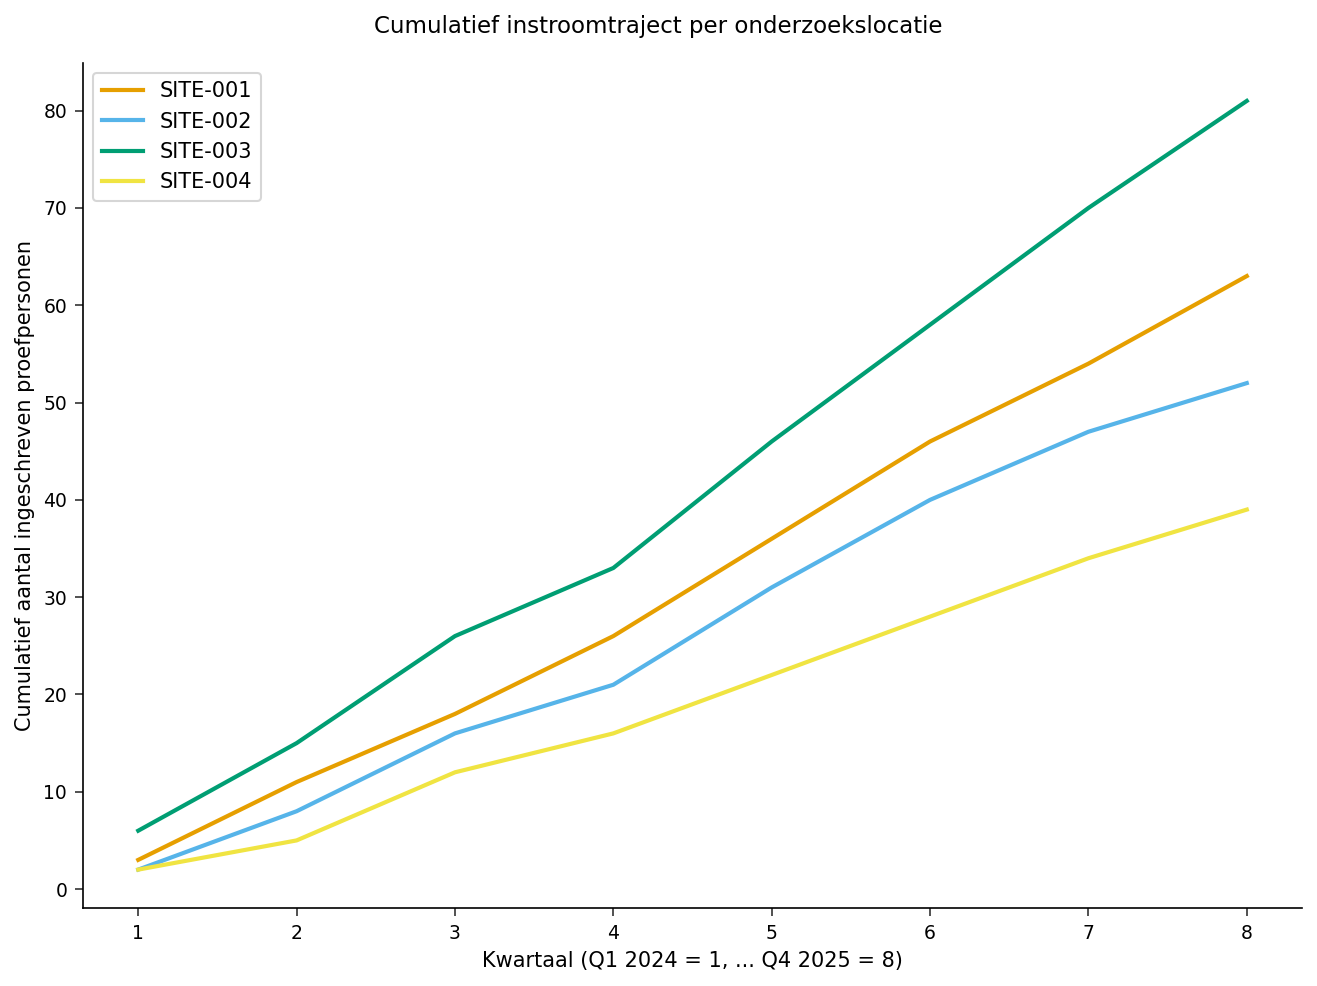

In [4]:
/* --------------------------------------------------------
   Kwartaal-cumulatief-instroomtraject per locatie.
   Uitgezet tegen een kwartaalindex (1..8) voor een
   overzichtelijke as.
   -------------------------------------------------------- */
GEGEVENS work.traj;
    INSTELLEN work.enrollment_qtr;
    VOLGENS site_id;
    BEHOUDEN quarter_index 0;
    ALS first.site_id DAN quarter_index = 0;
    quarter_index + 1;
UITVOEREN;

PROCEDURE SGPLOT GEGEVENS=work.traj;
    SERIES x=quarter_index y=cumulative_enrolled
        / GROUP=site_id LINEATTRS=(thickness=2) MARKERS;
    XAXIS label='Kwartaal (Q1 2024 = 1, ... Q4 2025 = 8)'
        integer VALUES=(1 TOT 8 VOLGENS 1);
    YAXIS label='Cumulatief aantal ingeschreven proefpersonen';
    TITEL 'Cumulatief instroomtraject per onderzoekslocatie';
UITVOEREN;


---

In [5]:
/* --------------------------------------------------------
   PROC EXPAND vereist dat de ID-variabele binnen elke
   BY-groep gesorteerd is, dus sorteer op locatie en
   vervolgens op kwartaal vóór de omzetting.
   -------------------------------------------------------- */
PROCEDURE SORTEREN GEGEVENS=work.enrollment_qtr;
    VOLGENS site_id quarter_date;
UITVOEREN;



NOTE: PROC SORT data=work.enrollment_qtr

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 32 rows from work.enrollment_qtr.
NOTE: Wrote work.enrollment_qtr (32 rows, 5 columns).
NOTE: PROC SORT statement used.


In [6]:
/* --------------------------------------------------------
   Zet kwartaalinstroom om naar maandelijkse schattingen.

   FROM=QTR / TO=MONTH op de PROC-instructie bepalen de invoer-
   en uitvoerfrequentie; PROC EXPAND interpoleert elke BY-groep
   (locatie) afzonderlijk langs de ID-datum.

   enrolled_count      -> METHOD=JOIN   (stuksgewijs lineair; de
                          instroomwaarde blijft niet-negatief
                          tussen ankerpunten)
   cumulative_enrolled -> METHOD=SPLINE (gladde monotone curve)
   -------------------------------------------------------- */
PROCEDURE expand GEGEVENS=work.enrollment_qtr
            out=work.enrollment_monthly
            FROM=qtr TOT=month;
    VOLGENS site_id;
    id quarter_date;
    convert enrolled_count      / observed=average METHOD=JOIN;
    convert cumulative_enrolled / observed=EINDE     METHOD=SPLINE;
UITVOEREN;


                                          Kwartaalinstroom-basislijn per regio                                          




NOTE: PROC EXPAND data=work.enrollment_qtr

NOTE: Expand Variables: enrolled_count, cumulative_enrolled
NOTE: Using Python pandas for frequency conversion
NOTE: Output dataset 'work.enrollment_monthly' has 96 observations.
NOTE: PROC EXPAND step completed.


                                          Kwartaalinstroom-basislijn per regio                                          




NOTE: DATA work.enrollment_monthly


NOTE: Read 96 rows from work.enrollment_monthly.
NOTE: Wrote work.enrollment_monthly (96 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC SGPLOT data=work.enrollment_monthly

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


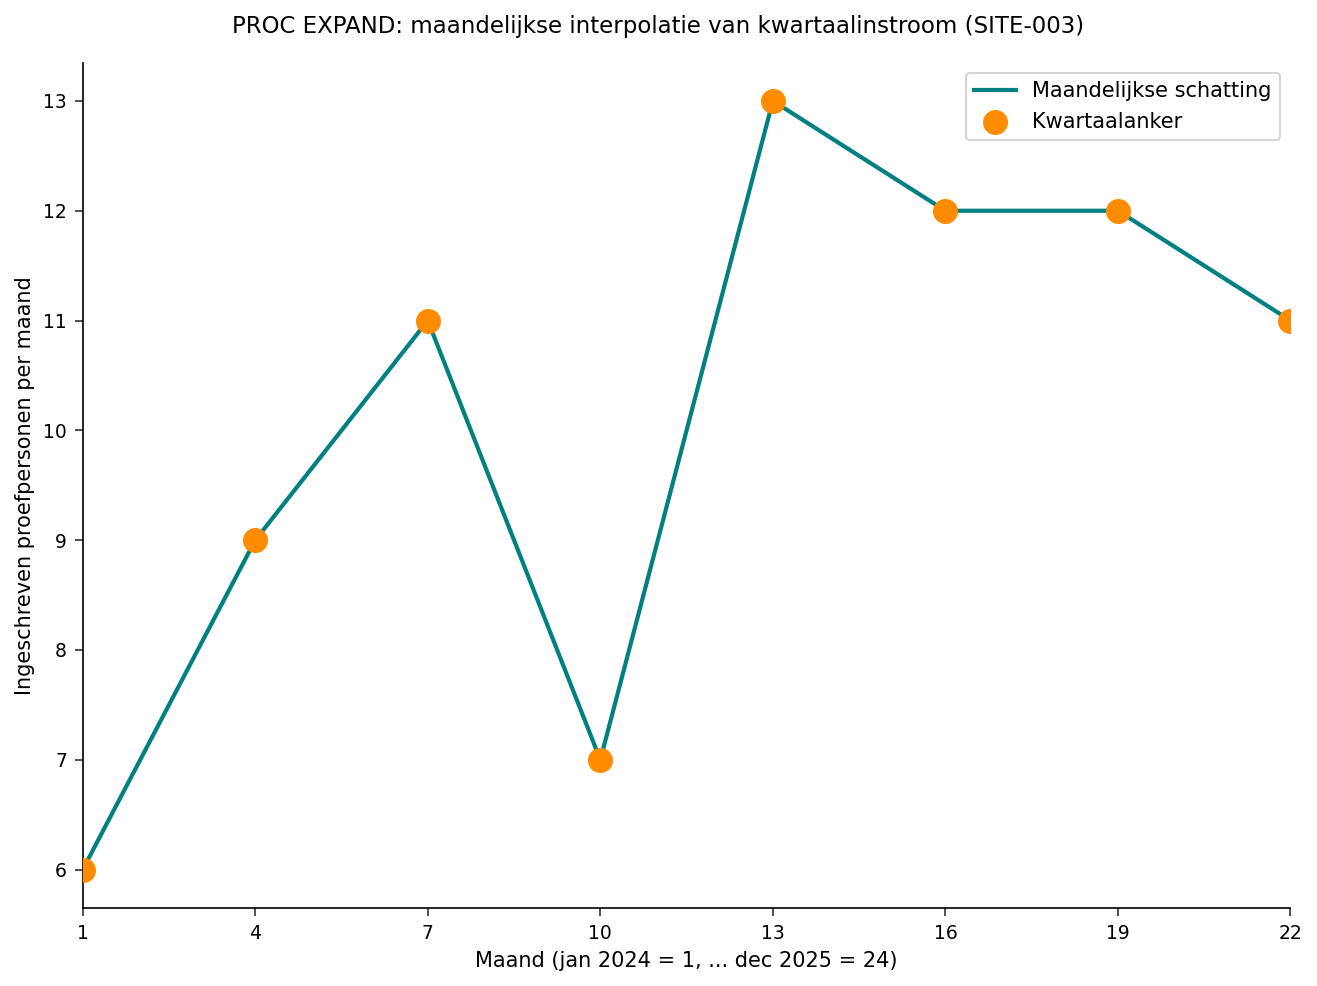

In [7]:
/* --------------------------------------------------------
   De ID-variabele bevat nu maandelijkse datums. Formatteer
   deze opnieuw en voeg een locatie-interne maandindex (1..24)
   toe voor de plot.
   -------------------------------------------------------- */
GEGEVENS work.enrollment_monthly;
    INSTELLEN work.enrollment_monthly;
    VOLGENS site_id;
    OPMAAK month_date monyy7.;
    month_date = quarter_date;
    BEHOUDEN month_index 0;
    ALS first.site_id DAN month_index = 0;
    month_index + 1;
    /* markeer de kwartaalankermaanden (1, 4, 7, ...) */
    ALS mod(month_index - 1, 3) = 0 DAN anchor = enrolled_count;
    ANDERS anchor = .;
UITVOEREN;

/* Toon de omzetting voor één locatie: de geïnterpoleerde
   maandelijkse lijn loopt door de oorspronkelijke
   kwartaalankerpunten. */
PROCEDURE SGPLOT GEGEVENS=work.enrollment_monthly;
    WAAR site_id = 'SITE-003';
    SERIES x=month_index y=enrolled_count
        / LINEATTRS=(thickness=2 color=teal)
          legendlabel='Maandelijkse schatting';
    SCATTER x=month_index y=anchor
        / MARKERATTRS=(SYMBOL=circlefilled size=11 color=darkorange)
          legendlabel='Kwartaalanker';
    XAXIS label='Maand (jan 2024 = 1, ... dec 2025 = 24)'
        integer VALUES=(1 TOT 24 VOLGENS 3);
    YAXIS label='Ingeschreven proefpersonen per maand';
    TITEL "PROC EXPAND: maandelijkse interpolatie van kwartaalinstroom (SITE-003)";
UITVOEREN;


In [8]:
/* --------------------------------------------------------
   Koppel de maandelijkse schattingen aan de locatiegegevens
   en vat vervolgens de maandelijkse instroom samen per regio.
   -------------------------------------------------------- */
PROCEDURE SQL;
    CREATE TABLE work.enrollment_monthly_region AS
    SELECTEREN e.site_id, s.region, e.month_date,
           e.enrolled_count      AS monthly_estimate,
           e.cumulative_enrolled AS cumulative_estimate
    FROM work.enrollment_monthly e
    INNER JOIN work.site_master s
        ON e.site_id = s.site_id
    ORDER VOLGENS s.region, e.site_id, e.month_date;
QUIT;

PROCEDURE GEMIDDELDEN GEGEVENS=work.enrollment_monthly_region n sum mean;
    KLASSE region;
    VARIABELE monthly_estimate cumulative_estimate;
    label region='Regio' monthly_estimate='Maandelijkse schatting'
          cumulative_estimate='Cumulatieve schatting';
    UITVOER out=work.region_monthly_summary
        sum(monthly_estimate)=total_monthly_enrolled
        mean(monthly_estimate)=avg_monthly_rate;
UITVOEREN;

PROCEDURE AFDRUKKEN GEGEVENS=work.region_monthly_summary noobs label;
    label region='Regio' total_monthly_enrolled='Totaal maandelijks ingeschreven'
          avg_monthly_rate='Gemiddeld maandelijks tempo';
    TITEL 'Maandelijkse schattingen per regio';
UITVOEREN;


                                          Kwartaalinstroom-basislijn per regio                                          

                                          Kwartaalinstroom-basislijn per regio                                          

                                                  The MEANS Procedure

                              Analysis Variable : monthly_estimate Maandelijkse schatting

        Regio                  N Obs            Sum           Mean
        ----------------------------------------------------------
        EUROPA                    44    336.0000000      7.6363636
        NOORD_AMERIKA             44    326.0000000      7.4090909
        ----------------------------------------------------------

                             Analysis Variable : cumulative_estimate Cumulatieve schatting

        Regio                  N Obs            Sum           Mean
        ----------------------------------------------------------
        EUROPA                  


NOTE: PROC SQL 

NOTE: Table work.enrollment_monthly_region created.
NOTE: PROC SQL statement used.
NOTE: PROC MEANS
NOTE: Output dataset work.region_monthly_summary has 3 observations and 5 variables.
NOTE: PROC MEANS statement used.
NOTE: PROC PRINT data=work.region_monthly_summary

NOTE: PROC PRINT completed: 3 observations printed, 5 variables


---

### Interpretatie

PROC EXPAND zette de **32 kwartaalrecords** (4 locaties x 8 kwartalen) om in **96 maandrecords** via frequentieomzetting langs de datum van elke locatie. De geïnterpoleerde maandreeks loopt exact door de oorspronkelijke kwartaalankerwaarden, zoals de SITE-003-plot laat zien: de oranje punten zijn de acht gerapporteerde kwartaalaantallen en de turquoise lijn is de gedisaggregeerde maandschatting die ze verbindt.

Op maandbasis lopen de twee regio's dicht bij elkaar. Europe komt gemiddeld uit op **7.64** geworven proefpersonen per locatie-maand en North America op **7.41**, met regionale maandtotalen van **336** en **326** proefpersonen over de geïnterpoleerde horizon. Omdat `METHOD=JOIN` niet extrapoleert voorbij het laatste kwartaalanker, dragen de laatste maanden van een gedeeltelijk kwartaal geen schatting en worden ze uitgesloten van de maandgemiddelden, wat de conservatieve keuze is voor toekomstige planning.

Deze maandprojecties stellen clinical operations in staat om van een kwartaal- naar een maandelijkse planningscadans over te gaan -- het bepalen van de omvang van geneesmiddelenzendingen, het inplannen van monitoringbezoeken en het rapporteren van de instroom aan de Data Safety Monitoring Board -- zonder ook maar een van de kwartaalcijfers te herzien die de studie al heeft vastgezet.


---

In [9]:
/* --------------------------------------------------------
   Exporteer maandelijkse instroomprojecties voor
   downstream-planningstools.
   -------------------------------------------------------- */
PROCEDURE EXPORTEREN GEGEVENS=work.enrollment_monthly_region
    OUTFILE='monthly_enrollment_projections.csv'
    DBMS=csv REPLACE;
UITVOEREN;

PROCEDURE EXPORTEREN GEGEVENS=work.region_monthly_summary
    OUTFILE='region_monthly_enrollment_summary.csv'
    DBMS=csv REPLACE;
UITVOEREN;



NOTE: PROC EXPORT data=work.enrollment_monthly_region outfile=monthly_enrollment_projections.csv

NOTE: Exported 96 rows to monthly_enrollment_projections.csv.
NOTE: PROC EXPORT data=work.region_monthly_summary outfile=region_monthly_enrollment_summary.csv

NOTE: Exported 3 rows to region_monthly_enrollment_summary.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Vertrouwelijk
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Mogelijk gemaakt door <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>